## Distributed Data Systems Project
#### Student Names: Daragh Brady (D00255640), James Lawrence (D00257516), Michael Sanei (D00260668)
#### Project Name: Alcohol Consumption

## Decision Tree

In [2]:
# Importing all the libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

In [3]:
# Load the dataset
data=pd.read_csv("student-mat.csv") 

# Explore the first few rows of the dataset
data.head() 

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,StudentID
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,3
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,4
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,5


Feature Engineering

In [4]:
# school
data['school']=data['school'].map({'GP':1,'MS':2})

# sex
data['sex']=data['sex'].map({'F':1,'M':2})

# address
data['address']=data['address'].map({'U':1,'R':2})

# famsize
data['famsize']=data['famsize'].map({'LE3':1,'GT3':2})

# Pstatus
data['Pstatus']=data['Pstatus'].map({'A':1,'T':2})

# Mjob
data['Mjob']=data['Mjob'].map({'teacher':1,'health':2,'services':3,'at_home':4,'other':5})

# Fjob
data['Fjob']=data['Fjob'].map({'teacher':1,'health':2,'services':3,'at_home':4,'other':5})

# reason
data['reason']=data['reason'].map({'home':1,'reputation':2,'course':3,'other':4})

# guardian
data['guardian']=data['guardian'].map({'mother':1,'father':2,'other':3})

# schoolsup
data['schoolsup']=data['schoolsup'].map({'yes':1,'no':2})

# famsup
data['famsup']=data['famsup'].map({'yes':1,'no':2})

# paid
data['paid']=data['paid'].map({'yes':1,'no':2})

# activities
data['activities']=data['activities'].map({'yes':1,'no':2})

# nursery
data['nursery']=data['nursery'].map({'yes':1,'no':2})

# higher
data['higher']=data['higher'].map({'yes':1,'no':2})

# internet
data['internet']=data['internet'].map({'yes':1,'no':2})

# romantic
data['romantic']=data['romantic'].map({'yes':1,'no':2})

# passing grade, as the grades are out of 20, we can use 8 (40%) as the passing mark
data['passed']=((data['G1'] > 8) & (data['G2'] > 8) & (data['G3'] > 8)).astype(int)

# drop unnecessary columns
data=data.drop(['G1','G2','G3','StudentID'],axis=1)

In [5]:
data['passed'].value_counts()

passed
1    257
0    138
Name: count, dtype: int64

Machine Learning

In [6]:
# Split the dataset into features and the target variable
y = data['passed']
x_full = data.drop('passed', axis=1)

In [20]:
x_with_constant = sm.add_constant(x_full)  # Add a constant term for the intercept
model = sm.OLS(y, x_with_constant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 passed   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     4.132
Date:                Tue, 10 Dec 2024   Prob (F-statistic):           3.59e-11
Time:                        11:53:52   Log-Likelihood:                -210.01
No. Observations:                 395   AIC:                             482.0
Df Residuals:                     364   BIC:                             605.4
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3824      0.443      0.863      0.3

We can see here that only the sex, studytime, failures, and schoolsup are significant. So we will use these features for our decision tree.

In [8]:
# make a new df with only the features that are significant 
x = data[['sex', 'studytime', 'failures', 'schoolsup']]

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [16]:
# New regression model
model1 = sm.OLS(y, x).fit()
print(model1.summary())

                                 OLS Regression Results                                
Dep. Variable:                 passed   R-squared (uncentered):                   0.719
Model:                            OLS   Adj. R-squared (uncentered):              0.716
Method:                 Least Squares   F-statistic:                              250.3
Date:                Tue, 10 Dec 2024   Prob (F-statistic):                   2.19e-106
Time:                        11:28:30   Log-Likelihood:                         -224.81
No. Observations:                 395   AIC:                                      457.6
Df Residuals:                     391   BIC:                                      473.5
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Accuracy of Decision Tree classifier on test: 0.71
Classification report:
              precision    recall  f1-score   support

           0       0.78      0.38      0.51        48
           1       0.69      0.93      0.79        71

    accuracy                           0.71       119
   macro avg       0.74      0.65      0.65       119
weighted avg       0.73      0.71      0.68       119



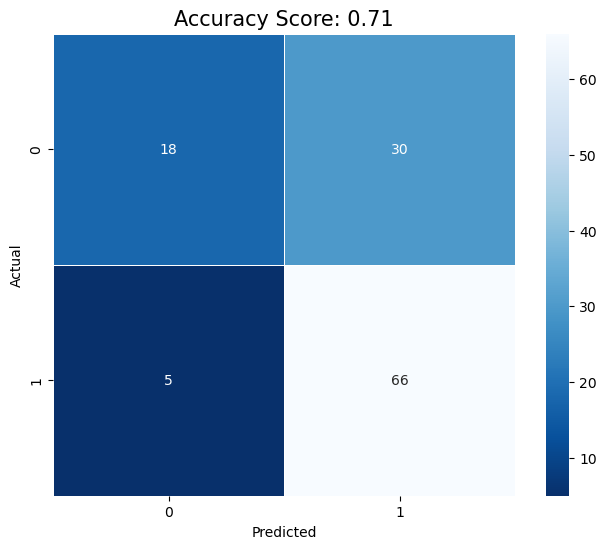

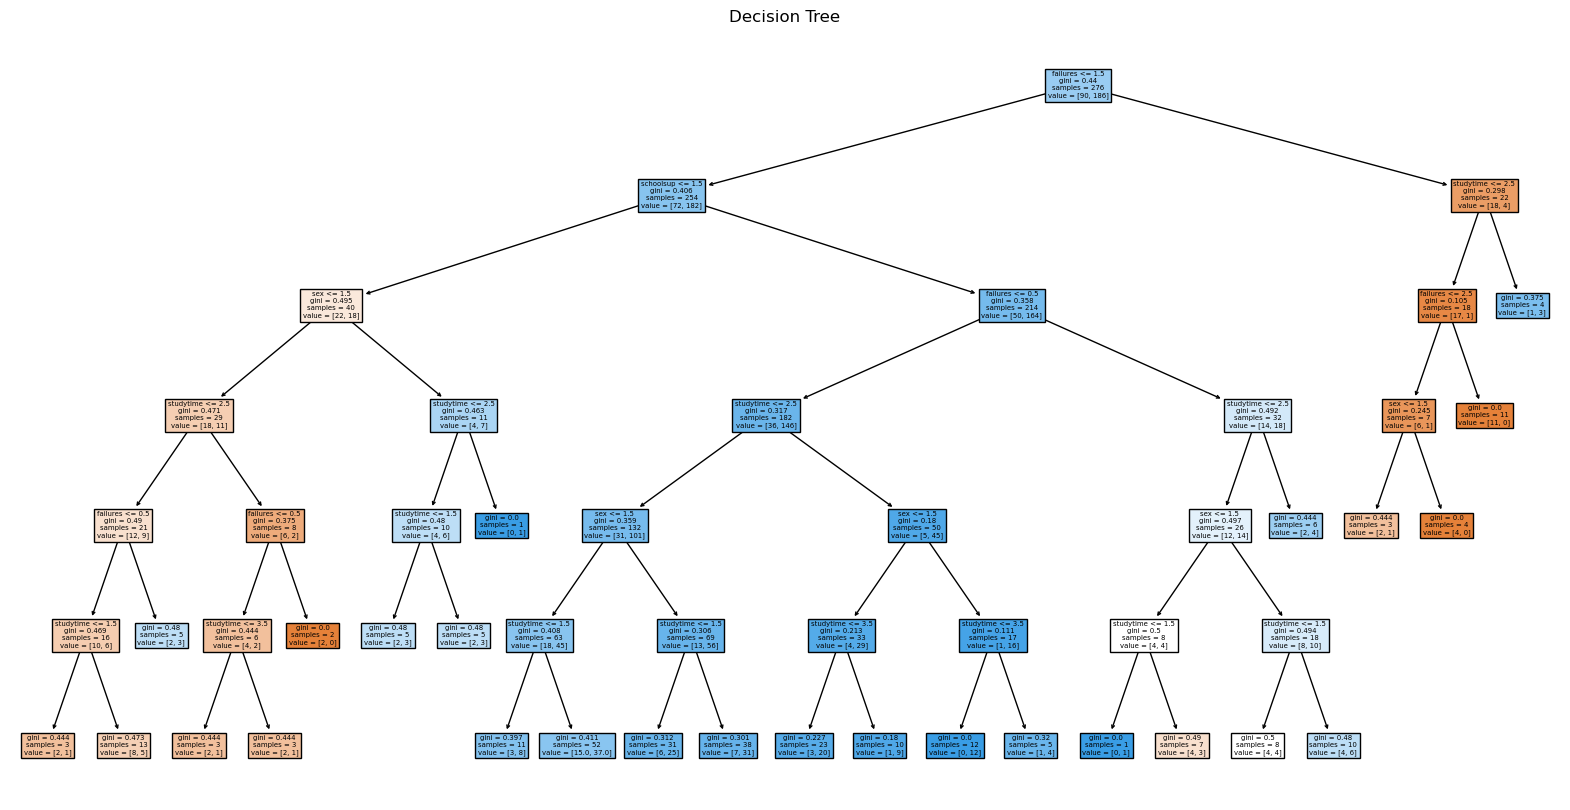

In [19]:
clf = DecisionTreeClassifier(criterion='gini') 

clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of Decision Tree classifier on test: {accuracy:.2f}')
print("Classification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Accuracy Score: {accuracy:.2f}', size=15)
plt.show()

plt.figure(figsize=(20, 10))
tree.plot_tree(clf, filled=True, feature_names=x.columns)
plt.title("Decision Tree")
plt.show()

Accuracy of 71% is quite good.